In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
##Load dataset and dataframe
data = pd.read_csv('Desktop/SANDY EXCEL/Housing.csv')
df = pd.DataFrame(data)
print('Loadset dataset with shape:' , df.shape)
df.head()

Loadset dataset with shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
##Data cleaning Process
print('\nMissing:')   ##Chceking misiing value
print(df.isnull().sum().sort_values(ascending=False).head(30))


Missing:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [6]:
dup = df.duplicated().sum()                     ##checking duplicates 
print('\n Number of duplicates :', dup)


 Number of duplicates : 0


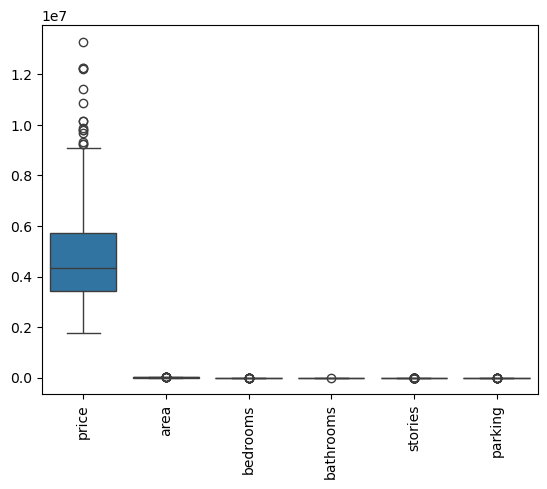

In [7]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [8]:
def handling_outliers(df, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []
    
    for col in df.select_dtypes(include='number').columns:
        if col in exclude_cols:
            continue  # skip target or excluded columns
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)
        
        # Capping outliers
        df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound 
                                else upper_bound if x > upper_bound else x)
    return df

In [9]:
# Apply the outlier handling function
df1 = handling_outliers(df, exclude_cols=['price'])
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420.0,4.0,2.0,3.0,yes,no,no,no,yes,2.0,yes,furnished
1,12250000,8960.0,4.0,3.5,3.5,yes,no,no,no,yes,2.5,no,furnished
2,12250000,9960.0,3.0,2.0,2.0,yes,no,yes,no,no,2.0,yes,semi-furnished
3,12215000,7500.0,4.0,2.0,2.0,yes,no,yes,no,yes,2.5,yes,furnished
4,11410000,7420.0,4.0,1.0,2.0,yes,yes,yes,no,yes,2.0,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000.0,2.0,1.0,1.0,yes,no,yes,no,no,2.0,no,unfurnished
541,1767150,2400.0,3.0,1.0,1.0,no,no,no,no,no,0.0,no,semi-furnished
542,1750000,3620.0,2.0,1.0,1.0,yes,no,no,no,no,0.0,no,unfurnished
543,1750000,2910.0,3.0,1.0,1.0,no,no,no,no,no,0.0,no,furnished


In [10]:
from sklearn.preprocessing import OneHotEncoder

In [11]:
oh = OneHotEncoder(sparse_output=False)

In [12]:
encoded = oh.fit_transform(df[['mainroad']])

In [13]:
encoded_df = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['mainroad']))

In [14]:
df1 = pd.concat([df.drop('mainroad',axis=1),encoded_df],axis=1)

In [15]:
encoded_df

,mainroad_no,mainroad_yes
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
540,0.0,1.0
541,1.0,0.0
542,0.0,1.0
543,1.0,0.0


In [16]:
encoded1 = oh.fit_transform(df1[['guestroom']])
encoded_df1 = pd.DataFrame(encoded1,columns=oh.get_feature_names_out(['guestroom']))
df1 = pd.concat([df1.drop('guestroom',axis=1),encoded_df1],axis=1)
encoded_df1

,guestroom_no,guestroom_yes
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,0.0,1.0
...,...,...
540,1.0,0.0
541,1.0,0.0
542,1.0,0.0
543,1.0,0.0


In [17]:
encoded2 = oh.fit_transform(df1[['basement']])
encoded_df2 = pd.DataFrame(encoded2,columns=oh.get_feature_names_out(['basement']))
df1 = pd.concat([df1.drop('basement',axis=1),encoded_df2],axis=1)
encoded_df2

,basement_no,basement_yes
0,1.0,0.0
1,1.0,0.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
540,0.0,1.0
541,1.0,0.0
542,1.0,0.0
543,1.0,0.0


In [18]:
encoded3 = oh.fit_transform(df1[['hotwaterheating']])
encoded_df3 = pd.DataFrame(encoded3,columns=oh.get_feature_names_out(['hotwaterheating']))
df1 = pd.concat([df1.drop('hotwaterheating',axis=1),encoded_df3],axis=1)
encoded_df3

,hotwaterheating_no,hotwaterheating_yes
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
540,1.0,0.0
541,1.0,0.0
542,1.0,0.0
543,1.0,0.0


In [19]:
encoded4 = oh.fit_transform(df1[['airconditioning']])
encoded_df4 = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['airconditioning']))
df1 = pd.concat([df1.drop('airconditioning',axis=1),encoded_df4],axis=1)
encoded_df4

,airconditioning_no,airconditioning_yes
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
540,0.0,1.0
541,1.0,0.0
542,0.0,1.0
543,1.0,0.0


In [20]:
encoded5 = oh.fit_transform(df1[['parking']])
encoded_df5 = pd.DataFrame(encoded5,columns=oh.get_feature_names_out(['parking']))
df1 = pd.concat([df1.drop('parking',axis=1),encoded_df5],axis=1)
encoded_df5

,parking_0.0,parking_1.0,parking_2.0,parking_2.5
0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0
...,...,...,...,...
540,0.0,0.0,1.0,0.0
541,1.0,0.0,0.0,0.0
542,1.0,0.0,0.0,0.0
543,1.0,0.0,0.0,0.0


In [21]:
encoded6 = oh.fit_transform(df1[['prefarea']])
encoded_df6 = pd.DataFrame(encoded6,columns=oh.get_feature_names_out(['prefarea']))
df1 = pd.concat([df1.drop('prefarea',axis=1),encoded_df6],axis=1)
encoded_df6

,prefarea_no,prefarea_yes
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
540,1.0,0.0
541,1.0,0.0
542,1.0,0.0
543,1.0,0.0


In [22]:
encoded7 = oh.fit_transform(df1[['furnishingstatus']])
encoded_df7 = pd.DataFrame(encoded7,columns=oh.get_feature_names_out(['furnishingstatus']))
df1 = pd.concat([df1.drop('furnishingstatus',axis=1),encoded_df7],axis=1)
encoded_df7

,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
540,0.0,0.0,1.0
541,0.0,1.0,0.0
542,0.0,0.0,1.0
543,1.0,0.0,0.0


In [23]:
# Identify numeric columns (int types)
num_cols = df1.select_dtypes(include=['int64']).columns.tolist()

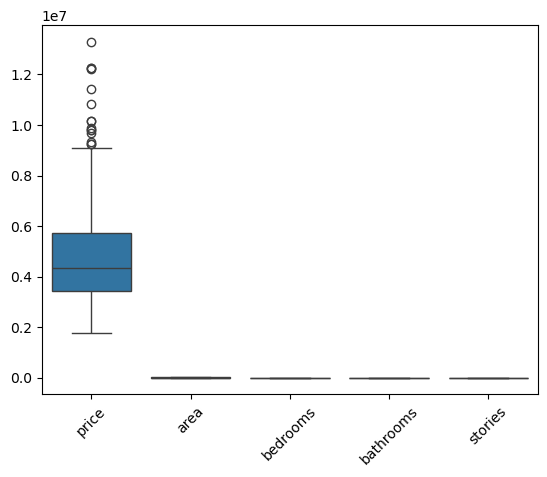

In [60]:
cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories']

sns.boxplot(data=df1[cols])
plt.xticks(rotation=45)
plt.show()

<Axes: >

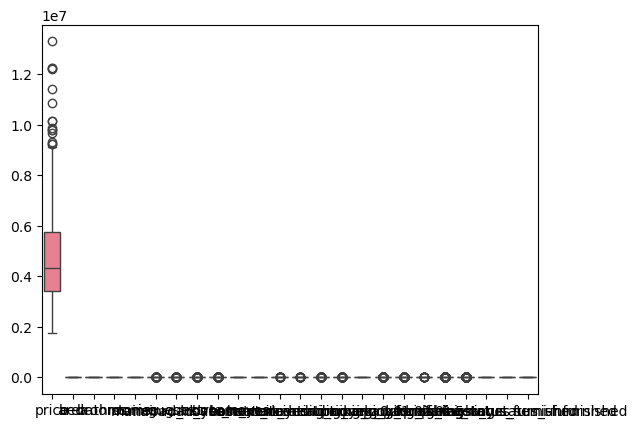

In [25]:
#Boxplot for df1 DataFrame
sns.boxplot(data=df1)
plt.x

In [26]:
from sklearn.preprocessing import LabelEncoder


# Copy original DataFrame to avoid modifying in place
df_encoded = df1.copy()

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

# Initialize the encoder
le = LabelEncoder()

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Label encoding complete!")
print("Encoded DataFrame shape:", df_encoded.shape)
df_encoded.head()


Label encoding complete!
Encoded DataFrame shape: (545, 24)


,price,area,bedrooms,bathrooms,stories,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,...,airconditioning_yes,parking_0.0,parking_1.0,parking_2.0,parking_2.5,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420.0,4.0,2.0,3.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,12250000,8960.0,4.0,3.5,3.5,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,12250000,9960.0,3.0,2.0,2.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,12215000,7500.0,4.0,2.0,2.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,11410000,7420.0,4.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [27]:
df1.dtypes

price                                int64
area                               float64
bedrooms                           float64
bathrooms                          float64
stories                            float64
mainroad_no                        float64
mainroad_yes                       float64
guestroom_no                       float64
guestroom_yes                      float64
basement_no                        float64
basement_yes                       float64
hotwaterheating_no                 float64
hotwaterheating_yes                float64
airconditioning_no                 float64
airconditioning_yes                float64
parking_0.0                        float64
parking_1.0                        float64
parking_2.0                        float64
parking_2.5                        float64
prefarea_no                        float64
prefarea_yes                       float64
furnishingstatus_furnished         float64
furnishingstatus_semi-furnished    float64
furnishings

In [29]:
a=df_encoded.corr(numeric_only=True)
a

,price,area,bedrooms,bathrooms,stories,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,...,airconditioning_yes,parking_0.0,parking_1.0,parking_2.0,parking_2.5,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
price,1.000000,0.549576,0.380282,0.514867,0.406114,-0.296898,0.296898,-0.255517,0.255517,-0.187057,...,0.296898,-0.372096,0.124323,0.300504,0.088358,-0.329777,0.329777,0.229350,0.063656,-0.280587
area,0.549576,1.000000,0.159563,0.198013,0.076002,-0.302767,0.302767,-0.162526,0.162526,-0.055157,...,0.302767,-0.347736,0.120366,0.249581,0.155447,-0.250572,0.250572,0.148883,0.013648,-0.153053
bedrooms,0.380282,0.159563,1.000000,0.379505,0.449893,0.006158,-0.006158,-0.088150,0.088150,-0.101888,...,-0.006158,-0.125332,0.010881,0.121212,0.064496,-0.092183,0.092183,0.074943,0.065406,-0.138575
bathrooms,0.514867,0.198013,0.379505,1.000000,0.314988,-0.042035,0.042035,-0.128477,0.128477,-0.104389,...,0.042035,-0.172774,0.070421,0.122000,0.052182,-0.065071,0.065071,0.105986,0.031663,-0.132024
stories,0.406114,0.076002,0.449893,0.314988,1.000000,-0.116145,0.116145,-0.037142,0.037142,0.164196,...,0.116145,-0.045562,0.054601,-0.008486,0.020689,-0.051317,0.051317,0.089176,0.005697,-0.089068
mainroad_no,-0.296898,-0.302767,0.006158,-0.042035,-0.116145,1.000000,-1.000000,0.092337,-0.092337,0.044002,...,-1.000000,0.166790,0.002476,-0.188433,-0.060862,0.199876,-0.199876,-0.129971,-0.011450,0.133123
mainroad_yes,0.296898,0.302767,-0.006158,0.042035,0.116145,-1.000000,1.000000,-0.092337,0.092337,-0.044002,...,1.000000,-0.166790,-0.002476,0.188433,0.060862,-0.199876,0.199876,0.129971,0.011450,-0.133123
guestroom_no,-0.255517,-0.162526,-0.088150,-0.128477,-0.037142,0.092337,-0.092337,1.000000,-1.000000,0.372066,...,-0.092337,0.059926,-0.052048,-0.033431,0.037129,0.160897,-0.160897,-0.099721,-0.005821,0.099023
guestroom_yes,0.255517,0.162526,0.088150,0.128477,0.037142,-0.092337,0.092337,-1.000000,1.000000,-0.372066,...,0.092337,-0.059926,0.052048,0.033431,-0.037129,-0.160897,0.160897,0.099721,0.005821,-0.099023
basement_no,-0.187057,-0.055157,-0.101888,-0.104389,0.164196,0.044002,-0.044002,0.372066,-0.372066,1.000000,...,-0.044002,0.029268,0.037927,-0.078634,0.005386,0.228083,-0.228083,-0.069852,-0.050284,0.117935


<Axes: >

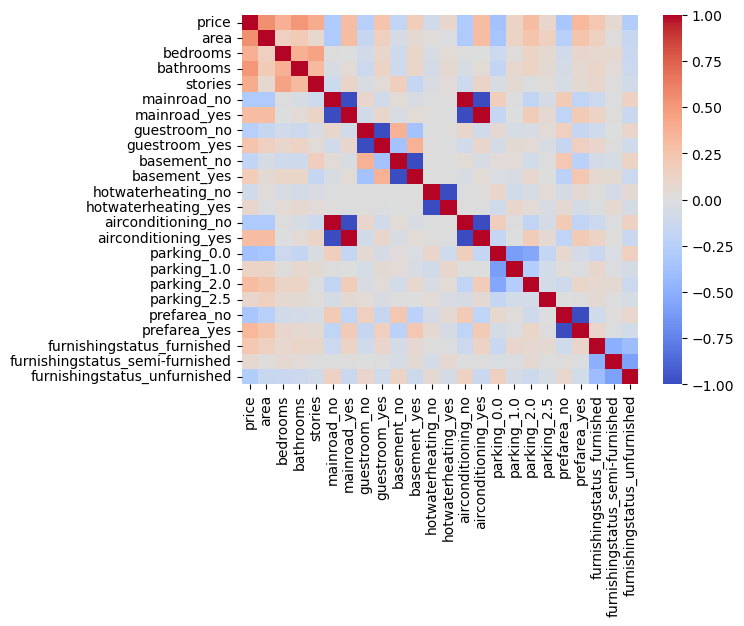

In [30]:
sns.heatmap(a,cmap='coolwarm')

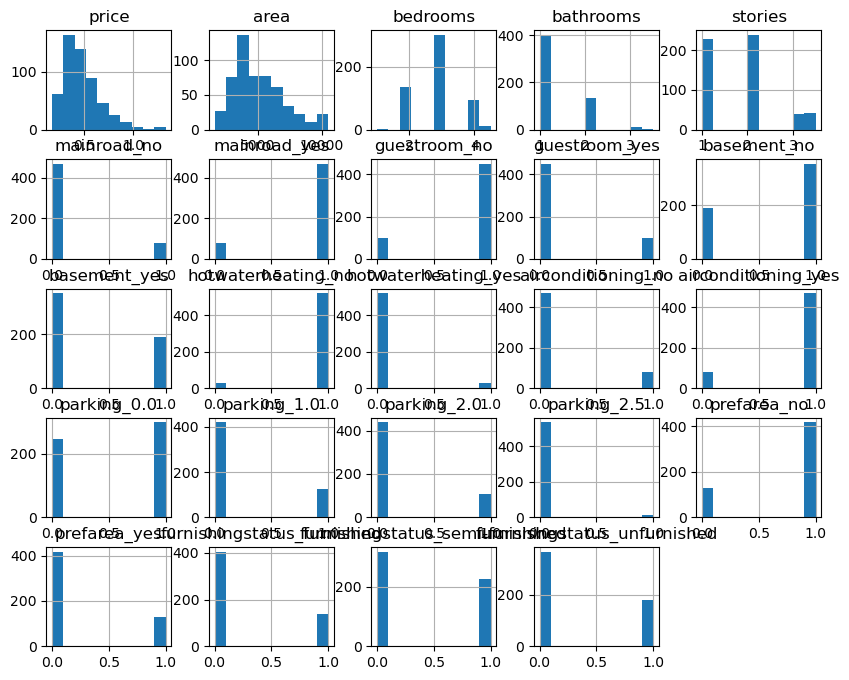

In [51]:
df1.hist(figsize=(10,8))
plt.show()

In [33]:
df1['price'].value_counts()

price
4200000    17
3500000    17
4900000    12
5250000     9
5600000     9
           ..
2135000     1
1960000     1
1855000     1
1820000     1
1767150     1
Name: count, Length: 219, dtype: int64

In [34]:
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

In [35]:
from  sklearn.feature_selection import SelectKBest,f_regression         # Apply SelectKBest
selector = SelectKBest(score_func=f_regression , k=13)                #select 13 features

X_new = selector.fit_transform(X,y)

#Get Select Feature names
selected_features = X.columns[selector.get_support()]

print("Top Select Features:")
print(selected_features)


Top Select Features:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad_no',
       'mainroad_yes', 'airconditioning_no', 'airconditioning_yes',
       'parking_0.0', 'parking_2.0', 'prefarea_no', 'prefarea_yes',
       'furnishingstatus_unfurnished'],
      dtype='object')


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [37]:
x_train,x_test,y_train,y_test = train_test_split(X,y ,test_size=0.2,random_state =42)

In [38]:
ss=StandardScaler()
x_train_scaled=ss.fit_transform(x_train)
x_test_scaled=ss.fit_transform(x_test)

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error

In [40]:
models={
    "LinearRegression" :LinearRegression(),
"DecisionTreeRegressor" : DecisionTreeRegressor(),
"RandomForestRegressor" : RandomForestRegressor()
}

In [41]:
result={}
for name, model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    result[name]={
        "y_pred": y_pred,
        "MSE":mean_squared_error(y_test,y_pred),
        "R2": r2_score (y_test, y_pred)
    }
    print(f"\n{name}")
    print("MSE:",result[name]["MSE"])
    print("R2:",result[name]["R2"])


LinearRegression
MSE: 1976883842313.8694
R2: 0.608891805641121

DecisionTreeRegressor
MSE: 2968352231651.376
R2: 0.41273894970810565

RandomForestRegressor
MSE: 2223553818706.381
R2: 0.5600904309703146
